# 导入数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_FLAIR"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
print(meta_df.head())
print(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 512)
metadata: (1189, 12)
   patient_id image_id                           image_path  Overall quality  \
0           1     1_l1  \regular-fundus-training\1\1_l1.jpg                0   
1           1     1_l2  \regular-fundus-training\1\1_l2.jpg                0   
2           1     1_r1  \regular-fundus-training\1\1_r1.jpg                0   
3           1     1_r2  \regular-fundus-training\1\1_r2.jpg                0   
4           2     2_l1  \regular-fundus-training\2\2_l1.jpg                0   

   left_eye_DR_Level  right_eye_DR_Level  patient_DR_Level  Clarity  \
0                0.0                 NaN                 0        8   
1                0.0                 NaN                 0        8   
2                NaN                 0.0                 0        8   
3                NaN                 0.0                 0       10   
4                2.0                 NaN                 2       10   

   Field definition  Artifact eye  eye_DR_Level  
0     

# PCA

方差贡献率
累计贡献率

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:
[0.23201725 0.16266784 0.15620737 0.07181212 0.06286059 0.04945781
 0.03809306 0.03570697 0.02992643 0.02647955]
Cumulative explained variance:
[0.23201725 0.3946851  0.5508925  0.62270457 0.6855652  0.73502296
 0.773116   0.808823   0.8387494  0.86522895]


累積寄与率plot

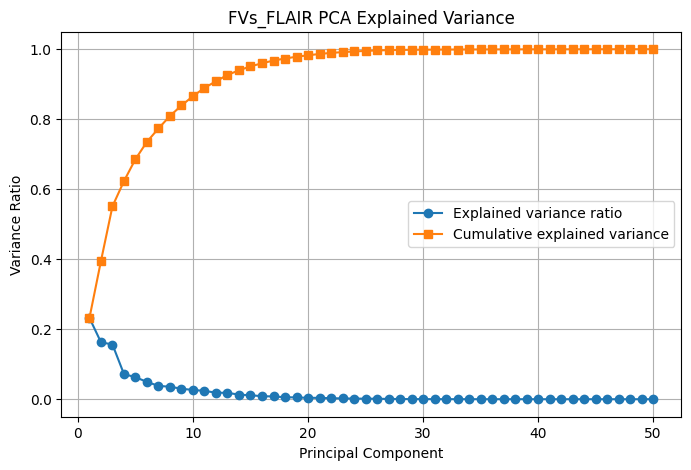

In [3]:
#医用基盤モデルの特徴空間には、少数の主要な方向により説明される構造が存在する。
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

将前十个打印出来看看

In [4]:
pca_df = meta_df.copy()

n_pcs_to_save = Z.shape[1] #50？

for i in range(n_pcs_to_save):
    pca_df[f"PC{i+1}"] = Z[:, i]

print(pca_df[["image_id", "patient_id", "eye", "eye_DR_Level", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]].head())

  image_id  patient_id eye  eye_DR_Level        PC1       PC2       PC3  \
0     1_l1           1   l           0.0  -4.319010 -7.089458 -3.185874   
1     1_l2           1   l           0.0  -9.331719 -5.353832 -7.797466   
2     1_r1           1   r           0.0  -4.721960  7.231561 -1.648031   
3     1_r2           1   r           0.0 -11.084781  1.464122  2.964018   
4     2_l1           2   l           2.0 -11.116131  4.018705 -0.417560   

         PC4       PC5       PC6        PC7       PC8       PC9      PC10  
0 -14.106559  0.550232  1.759339  -1.016277  2.153743  3.259699 -3.307727  
1 -12.000017  4.493600 -2.430102   4.087406 -0.860132 -0.055407 -5.297432  
2  -9.303661 -2.795426 -2.069839 -11.756225 -2.171170  0.848339  1.949078  
3  -4.531741 -3.897524  0.681876  -1.894142 -3.451779 -2.201083 -3.711227  
4   0.366197 -8.772405  0.345485  -3.511056 -3.401420 -0.819098  0.887782  


In [5]:
# 定义画图函数
def plot_pca_scatter(df, pc_x="PC1", pc_y="PC2", color_col="eye_DR_Level", title=None):
    plt.figure(figsize=(7, 6))
    
    labels = sorted(df[color_col].dropna().unique())
    
    for lab in labels:
        sub = df[df[color_col] == lab]
        plt.scatter(
            sub[pc_x],
            sub[pc_y],
            s=10,
            alpha=0.7,
            label=str(lab)
        )
    
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(title if title else f"{pc_x} vs {pc_y} colored by {color_col}")
    plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for i in range(50):
    pc = f"PC{i+1}"
    tmp = pca_df[[pc, "eye"]].dropna()
    
    y = (tmp["eye"] == "r").astype(int)
    score = tmp[pc].values
    
    auc = roc_auc_score(y, score)
    auc = max(auc, 1 - auc)
    
    left_vals = tmp[tmp["eye"] == "l"][pc]
    right_vals = tmp[tmp["eye"] == "r"][pc]
    
    cohen_d = abs(left_vals.mean() - right_vals.mean()) / np.sqrt(
        (left_vals.var() + right_vals.var()) / 2
    )
    
    rows.append({
        "PC": pc,
        "eye_AUC": auc,
        "cohen_d": cohen_d,
        "explained_var": pca.explained_variance_ratio_[i],
    })

eye_pc_table = pd.DataFrame(rows).sort_values("eye_AUC", ascending=False)
eye_pc_table.head(20)

,PC,eye_AUC,cohen_d,explained_var
42,PC43,0.572405,0.238431,0.000035
20,PC21,0.570235,0.254478,0.003904
17,PC18,0.555414,0.169133,0.005749
23,PC24,0.552333,0.181583,0.001867
22,PC23,0.552327,0.175953,0.002242
6,PC7,0.552081,0.164424,0.038093
3,PC4,0.549195,0.138802,0.071812
19,PC20,0.546267,0.159610,0.004053
49,PC50,0.545969,0.179416,0.000022
18,PC19,0.543627,0.157514,0.005106


In [7]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Strict fold-wise evaluation:
# PC1-k subspace eye prediction vs raw feature eye prediction
# ============================================================

# 标签
y_eye = (pca_df["eye"] == "r").astype(int).values
groups = pca_df["patient_id"].values

# 原始特征
X_input = X_raw

ks_requested = [10, 20, 50, 100, 200, 500]

# 实际可用的最大 PC 数
max_possible_k = min(
    max(ks_requested),
    X_input.shape[0] - 1,
    X_input.shape[1]
)

ks = [k for k in ks_requested if k <= max_possible_k]

print("X_input shape:", X_input.shape)
print("Evaluated PC subspaces:", ks)
print("Eye label distribution:")
print(pd.Series(y_eye).value_counts().sort_index())

X_input shape: (1189, 512)
Evaluated PC subspaces: [10, 20, 50, 100, 200, 500]
Eye label distribution:
0    594
1    595
Name: count, dtype: int64


In [8]:
def make_eye_classifier():
    return LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )


def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)


def calc_eye_metrics(y_true, pred, prob):
    return {
        "eye_accuracy": accuracy_score(y_true, pred),
        "eye_balanced_acc": balanced_accuracy_score(y_true, pred),
        "eye_AUC": safe_auc(y_true, prob)
    }

In [9]:
cv = GroupKFold(n_splits=5)

# out-of-fold prediction storage
pred_pc = {k: np.zeros_like(y_eye) for k in ks}
prob_pc = {k: np.zeros(len(y_eye), dtype=float) for k in ks}

pred_raw = np.zeros_like(y_eye)
prob_raw = np.zeros(len(y_eye), dtype=float)

fold_rows = []
cumvar_rows = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_input, y_eye, groups), start=1):
    
    print(f"Running fold {fold}...")
    
    X_train_raw = X_input[train_idx]
    X_test_raw = X_input[test_idx]
    
    y_train = y_eye[train_idx]
    y_test = y_eye[test_idx]
    
    # ========================================================
    # 1. X_raw baseline
    # ========================================================
    raw_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", make_eye_classifier())
    ])
    
    raw_clf.fit(X_train_raw, y_train)
    
    pred_raw_fold = raw_clf.predict(X_test_raw)
    prob_raw_fold = raw_clf.predict_proba(X_test_raw)[:, 1]
    
    pred_raw[test_idx] = pred_raw_fold
    prob_raw[test_idx] = prob_raw_fold
    
    raw_metrics = calc_eye_metrics(y_test, pred_raw_fold, prob_raw_fold)
    raw_metrics.update({
        "fold": fold,
        "feature": "X_raw",
        "k": np.nan,
        "cum_explained_var": np.nan
    })
    fold_rows.append(raw_metrics)
    
    # ========================================================
    # 2. Fold-wise scaler for PCA
    # ========================================================
    scaler_fold = StandardScaler()
    X_train_std = scaler_fold.fit_transform(X_train_raw)
    X_test_std = scaler_fold.transform(X_test_raw)
    
    # 当前 fold 可用的最大 PCA 维度
    max_k_fold = min(
        max(ks),
        X_train_std.shape[0] - 1,
        X_train_std.shape[1]
    )
    
    pca_fold = PCA(
        n_components=max_k_fold,
        random_state=0
    )
    
    Z_train = pca_fold.fit_transform(X_train_std)
    Z_test = pca_fold.transform(X_test_std)
    
    cum_explained = np.cumsum(pca_fold.explained_variance_ratio_)
    
    # ========================================================
    # 3. PC1-k subspace linear probe
    # ========================================================
    for k in ks:
        if k > max_k_fold:
            continue
        
        pc_clf = Pipeline([
            ("scaler", StandardScaler()),
            ("logreg", make_eye_classifier())
        ])
        
        pc_clf.fit(Z_train[:, :k], y_train)
        
        pred_fold = pc_clf.predict(Z_test[:, :k])
        prob_fold = pc_clf.predict_proba(Z_test[:, :k])[:, 1]
        
        pred_pc[k][test_idx] = pred_fold
        prob_pc[k][test_idx] = prob_fold
        
        pc_metrics = calc_eye_metrics(y_test, pred_fold, prob_fold)
        pc_metrics.update({
            "fold": fold,
            "feature": f"PC1-{k}",
            "k": k,
            "cum_explained_var": cum_explained[k - 1]
        })
        fold_rows.append(pc_metrics)
        
        cumvar_rows.append({
            "fold": fold,
            "feature": f"PC1-{k}",
            "k": k,
            "cum_explained_var": cum_explained[k - 1]
        })

Running fold 1...
Running fold 2...
Running fold 3...
Running fold 4...
Running fold 5...


In [10]:
fold_results_df = pd.DataFrame(fold_rows)
fold_results_df

,eye_accuracy,eye_balanced_acc,eye_AUC,fold,feature,k,cum_explained_var
0,0.679167,0.679167,0.766875,1,X_raw,NaN,NaN
1,0.525000,0.525000,0.558264,1,PC1-10,10.0,0.863437
2,0.550000,0.550000,0.594306,1,PC1-20,20.0,0.981458
3,0.591667,0.591667,0.633472,1,PC1-50,50.0,0.999319
4,0.670833,0.670833,0.757083,1,PC1-100,100.0,0.999764
5,0.762500,0.762500,0.844583,1,PC1-200,200.0,0.999936
6,0.733333,0.733333,0.791806,1,PC1-500,500.0,0.999999
7,0.701681,0.701681,0.764918,2,X_raw,NaN,NaN
8,0.529412,0.529412,0.513099,2,PC1-10,10.0,0.862313
9,0.621849,0.621849,0.626439,2,PC1-20,20.0,0.981834


In [11]:
# fold-wise mean/std
summary_df = (
    fold_results_df
    .groupby("feature")[["eye_accuracy", "eye_balanced_acc", "eye_AUC", "cum_explained_var"]]
    .agg(["mean", "std"])
)

summary_df

eye_accuracy           eye_balanced_acc             eye_AUC            \
                mean       std             mean       std      mean       std   
feature                                                                         
PC1-10      0.529881  0.031497         0.529854  0.031549  0.552318  0.044239   
PC1-100     0.709143  0.038652         0.709085  0.038613  0.770788  0.030142   
PC1-20      0.577869  0.034109         0.577861  0.034104  0.607942  0.019859   
PC1-200     0.751073  0.022850         0.751019  0.022900  0.825351  0.033012   
PC1-50      0.635184  0.044999         0.635147  0.044962  0.675506  0.039256   
PC1-500     0.752764  0.017547         0.752756  0.017556  0.802589  0.029687   
X_raw       0.719273  0.039040         0.719226  0.039017  0.786723  0.030964   

        cum_explained_var                
                     mean           std  
feature                                  
PC1-10           0.866236  3.520480e-03  
PC1-100          0.999770  4.628676e-06  
PC1-20           0.982136  5.309723e-04  
PC1-200          0.999938  1.439548e-06  
PC1-50           0.999334  1.351248e-05  
PC1-500          1.000000  1.912928e-07  
X_raw                 NaN           NaN

In [12]:
# pooled out-of-fold results
pooled_rows = []

for k in ks:
    metrics = calc_eye_metrics(y_eye, pred_pc[k], prob_pc[k])
    
    cumvar_mean = (
        fold_results_df[fold_results_df["feature"] == f"PC1-{k}"]["cum_explained_var"]
        .mean()
    )
    
    pooled_rows.append({
        "feature": f"PC1-{k}",
        "k": k,
        "eye_accuracy": metrics["eye_accuracy"],
        "eye_balanced_acc": metrics["eye_balanced_acc"],
        "eye_AUC": metrics["eye_AUC"],
        "cum_explained_var_mean": cumvar_mean
    })

raw_metrics = calc_eye_metrics(y_eye, pred_raw, prob_raw)

pooled_rows.append({
    "feature": "X_raw",
    "k": np.nan,
    "eye_accuracy": raw_metrics["eye_accuracy"],
    "eye_balanced_acc": raw_metrics["eye_balanced_acc"],
    "eye_AUC": raw_metrics["eye_AUC"],
    "cum_explained_var_mean": np.nan
})

pooled_results_df = pd.DataFrame(pooled_rows)
pooled_results_df

,feature,k,eye_accuracy,eye_balanced_acc,eye_AUC,cum_explained_var_mean
0,PC1-10,10.0,0.529857,0.529880,0.551014,0.866236
1,PC1-20,20.0,0.577796,0.577837,0.608086,0.982136
2,PC1-50,50.0,0.634987,0.635001,0.672280,0.999334
3,PC1-100,100.0,0.708999,0.709002,0.770005,0.999770
4,PC1-200,200.0,0.751051,0.751038,0.821436,0.999938
5,PC1-500,500.0,0.752733,0.752742,0.801865,1.000000
6,X_raw,NaN,0.719092,0.719101,0.785414,NaN


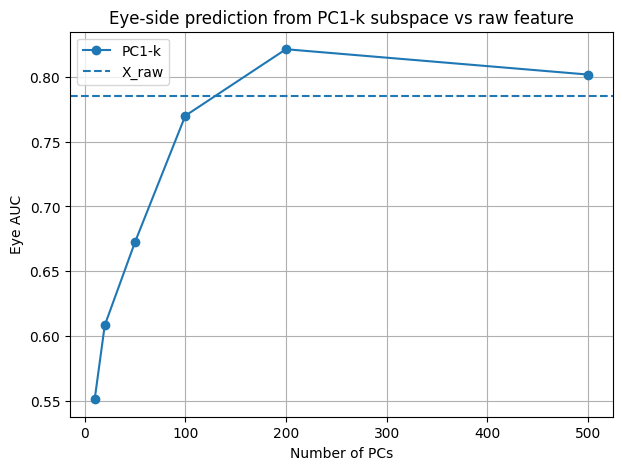

In [13]:
plot_df = pooled_results_df[pooled_results_df["feature"].str.startswith("PC1-")].copy()
raw_auc = pooled_results_df.loc[pooled_results_df["feature"] == "X_raw", "eye_AUC"].iloc[0]

plt.figure(figsize=(7, 5))
plt.plot(plot_df["k"], plot_df["eye_AUC"], marker="o", label="PC1-k")
plt.axhline(raw_auc, linestyle="--", label="X_raw")

plt.xlabel("Number of PCs")
plt.ylabel("Eye AUC")
plt.title("Eye-side prediction from PC1-k subspace vs raw feature")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

GRADE_COL = "patient_DR_Level"   # 这里改成你自己的病变等级列名，例如 "DR_grade"
N_PC = 50

def safe_auc(y_binary, score):
    """
    计算二分类AUC。
    如果只有一个类别，返回 NaN。
    因为PC方向正负是任意的，所以取 max(AUC, 1-AUC)。
    """
    y_binary = np.asarray(y_binary)
    score = np.asarray(score)

    if len(np.unique(y_binary)) < 2:
        return np.nan

    auc = roc_auc_score(y_binary, score)
    return max(auc, 1 - auc)


rows = []

for i in range(N_PC):
    pc = f"PC{i+1}"

    tmp = pca_df[[pc, GRADE_COL]].dropna()

    y_grade = tmp[GRADE_COL].astype(int)
    score = tmp[pc].values

    # 1. 等级与PC的单调相关性
    spearman_r, spearman_p = spearmanr(y_grade, score)

    # PC方向任意，所以相关系数也建议看绝对值
    spearman_abs = abs(spearman_r)

    # 2. 多个临床阈值下的AUC
    # grade >= 1 : 是否有病变
    # grade >= 2 : 是否中度及以上
    # grade >= 3 : 是否重度及以上
    # grade >= 4 : 是否PDR
    auc_ge_1 = safe_auc(y_grade >= 1, score)
    auc_ge_2 = safe_auc(y_grade >= 2, score)
    auc_ge_3 = safe_auc(y_grade >= 3, score)
    auc_ge_4 = safe_auc(y_grade >= 4, score)

    auc_list = [auc_ge_1, auc_ge_2, auc_ge_3, auc_ge_4]
    mean_threshold_auc = np.nanmean(auc_list)

    rows.append({
        "PC": pc,
        "grade_spearman_abs": spearman_abs,
        "grade_spearman": spearman_r,
        "grade_spearman_p": spearman_p,
        "AUC_grade>=1": auc_ge_1,
        "AUC_grade>=2": auc_ge_2,
        "AUC_grade>=3": auc_ge_3,
        "AUC_grade>=4": auc_ge_4,
        "mean_grade_AUC": mean_threshold_auc,
        "explained_var": pca.explained_variance_ratio_[i],
    })

grade_pc_table = pd.DataFrame(rows).sort_values(
    "mean_grade_AUC", ascending=False
)

grade_pc_table.head(20)

,PC,grade_spearman_abs,grade_spearman,grade_spearman_p,AUC_grade>=1,AUC_grade>=2,AUC_grade>=3,AUC_grade>=4,mean_grade_AUC,explained_var
0,PC1,0.807749,0.807749,1.107787e-274,0.909897,0.941112,0.919940,0.820268,0.897805,0.232017
1,PC2,0.192262,-0.192262,2.308438e-11,0.710750,0.659904,0.530623,0.647895,0.637293,0.162668
2,PC3,0.243647,0.243647,1.577568e-17,0.672327,0.615702,0.596281,0.569824,0.613533,0.156207
3,PC4,0.210735,0.210735,2.112458e-13,0.615056,0.600032,0.622128,0.568896,0.601528,0.071812
46,PC47,0.172169,0.172169,2.299159e-09,0.633615,0.572925,0.572014,0.524493,0.575762,0.000027
11,PC12,0.111017,-0.111017,1.250957e-04,0.569483,0.545677,0.528729,0.638369,0.570565,0.018723
5,PC6,0.015300,0.015300,5.981653e-01,0.517983,0.526201,0.571911,0.659269,0.568841,0.049458
7,PC8,0.067662,-0.067662,1.962996e-02,0.536092,0.549126,0.583940,0.597825,0.566746,0.035707
12,PC13,0.075636,0.075636,9.078927e-03,0.524899,0.553367,0.594857,0.553492,0.556654,0.018195
23,PC24,0.080403,0.080403,5.536682e-03,0.521717,0.559284,0.598207,0.537738,0.554237,0.001867
